## Experiment 1

### Import Libraries

In [1]:
import requests
import torch

from transformers import AutoProcessor, BlipForConditionalGeneration
from diffusers import DiffusionPipeline
from PIL import Image

import gradio as gr

### Image Captioning - BLIP

In [2]:
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [3]:
url = "https://c8.alamy.com/comp/C84HAM/herd-of-cows-on-alpine-pasture-among-mountains-in-alps-northern-italy-C84HAM.jpg"
image = Image.open(requests.get(url, stream=True).raw)

In [4]:
# using a sample from the LAION dataset

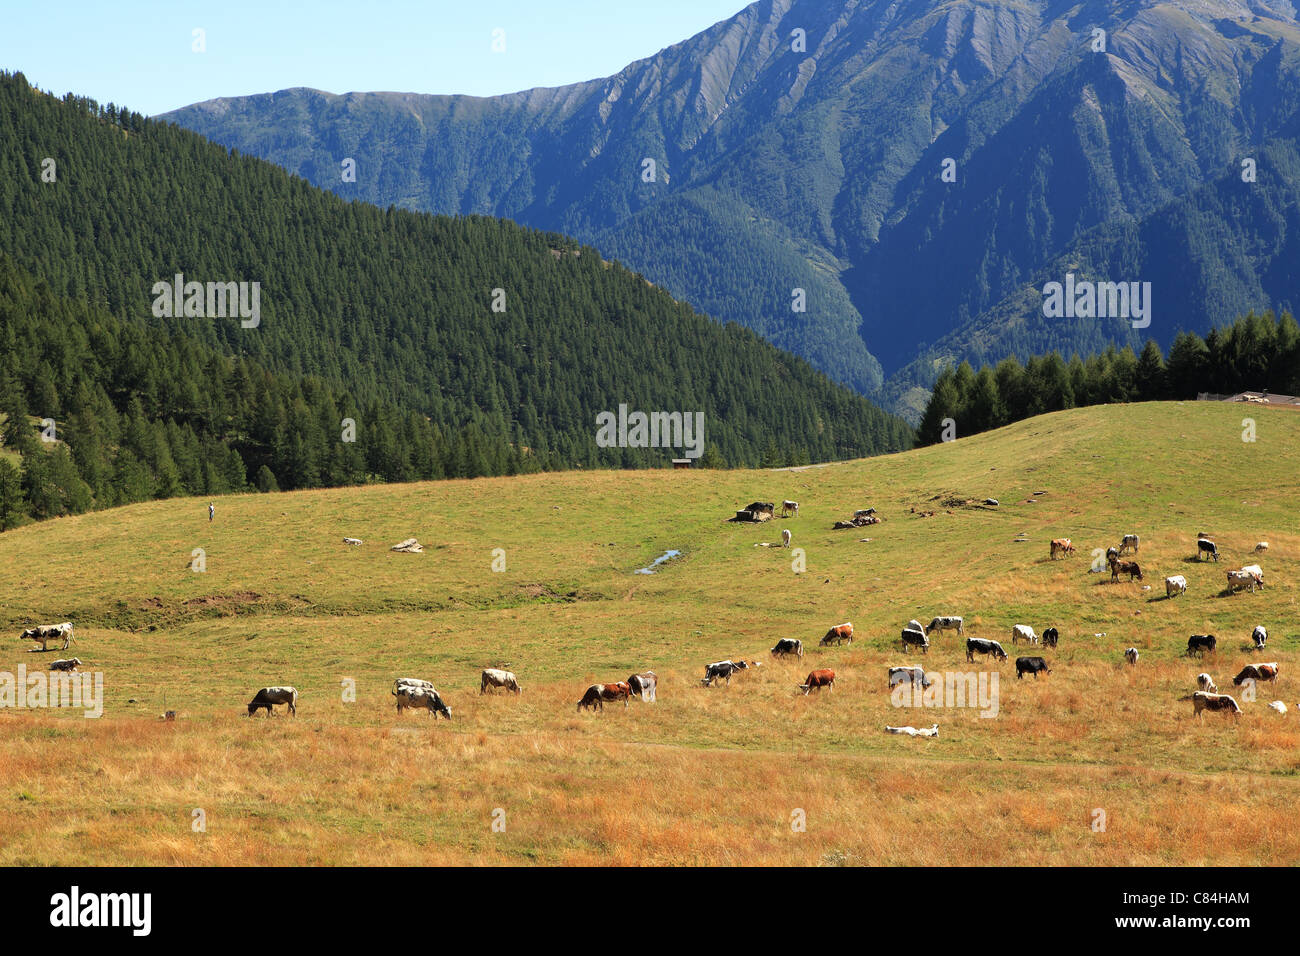

In [5]:
image

In [6]:
orginal_caption = "Herd of cows on alpine pasture among mountains in Alps, northern Italy. Stock Photo"
print(orginal_caption)

Herd of cows on alpine pasture among mountains in Alps, northern Italy. Stock Photo


In [7]:
inputs = processor(images=image, return_tensors="pt")
out = blip_model.generate(**inputs, max_length=40, num_beams=5)
text = processor.tokenizer.decode(out[0], skip_special_tokens=True).strip()

print(text)

a herd of cows grazing in the mountains of the austrian alps - stock image


### Image Generation - Stable Diffusion 1.5

In [8]:
text2img_pipe = DiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5")
text2img_pipe = text2img_pipe.to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

safety_checker/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

AcceleratorError: CUDA error: CUDA-capable device(s) is/are busy or unavailable
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
prompt = text
generator = torch.manual_seed(42)
gen_img_gen_cap = text2img_pipe(prompt, generator=generator).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

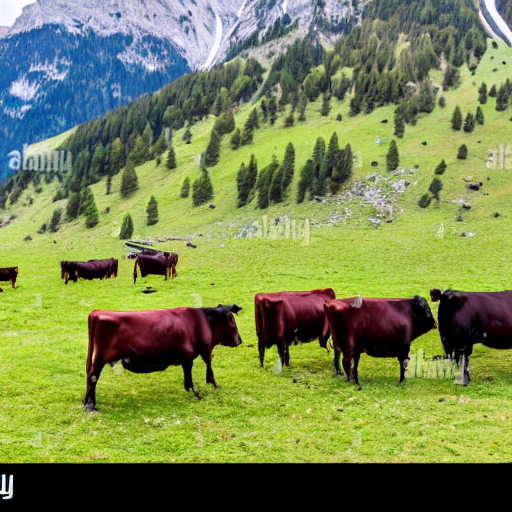

In [ ]:
gen_img_gen_cap

  0%|          | 0/50 [00:00<?, ?it/s]

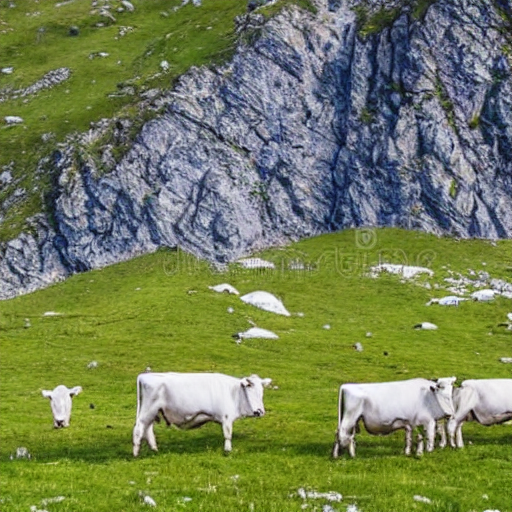

In [ ]:
prompt = orginal_caption
gen_img_ori_cap = text2img_pipe(prompt, generator=generator).images[0]
gen_img_ori_cap

### SD2

#### Text Encoder

In [ ]:
# Access the exact text encoder and tokenizer used by the pipeline
text_encoder = text2img_pipe.text_encoder
tokenizer = text2img_pipe.tokenizer

In [ ]:
text_encoder

CLIPTextModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e

In [ ]:
prompt = "a photo of an astronaut riding a horse"
inputs = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, return_tensors="pt").to("cuda")
with torch.no_grad():
    text_embeds = text_encoder(input_ids=inputs.input_ids)[0]
print(text_embeds.shape)

torch.Size([1, 77, 768])


In [ ]:
text_embeds

tensor([[[-0.3884,  0.0229, -0.0522,  ..., -0.4899, -0.3066,  0.0675],
         [ 0.0290, -1.3258,  0.3085,  ..., -0.5257,  0.9768,  0.6652],
         [ 1.1565,  0.1318,  0.7895,  ..., -2.1024, -1.1519, -0.3311],
         ...,
         [-3.0631, -0.0577, -0.3814,  ...,  0.3001, -0.1891,  0.6027],
         [-3.0724, -0.0791, -0.3841,  ...,  0.3117, -0.1861,  0.5978],
         [-3.0261, -0.0362, -0.3700,  ...,  0.3250, -0.1444,  0.5918]]],
       device='cuda:0')

#### Encoder

## Experiment 2

In [ ]:
import os
import argparse
import math
from pathlib import Path
from typing import List, Tuple

import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F

from transformers import (
    CLIPProcessor,
    CLIPModel,
    CLIPTextModel,
    CLIPTokenizer
)

In [ ]:
class ImageCaptionDataset(Dataset):
  """
  Simple dataset that reads 'image_path, caption' from a CSV file.

  CSV must contain columns named 'image_path' and 'caption' (customizable via args).
  We return PIL images (not tensors) and the caption string so batching can
  use the CLIPProcessor for images and the CLIPTokenizer for captions.
  """

  def __init___(self, csv_path: str, image_col: str='image_path', caption_col: str='caption'):
    df = pd.read_csv(csv_path)
    if image_col not in df.columns or caption_col not in df.columns:
      raise ValueError(f"CSV must contain columns {image_col} and {caption_col}")
    self.df = df
    self.image_col = image_col
    self.caption_col = caption_col

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    img_path = row[self.image_col]
    caption = row[self.caption_col]
    img = Image.open(img_path).convert('RGB')
    return img, caption

In [ ]:
ds = load_dataset("laion/relaion2B-en-research-safe", split="train", streaming=True)
subset = ds.shuffle(seed=42).take(10000000)

Resolving data files:   0%|          | 0/128 [00:00<?, ?it/s]

In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame(subset)

In [ ]:
df.columns

Index(['url', 'similarity', 'hash', 'pwatermark', 'punsafe', 'caption', 'key',
       'status', 'error_message', 'width', 'height', 'original_width',
       'original_height', 'exif', 'md5'],
      dtype='object')

In [ ]:
from datasets import load_dataset

ds = load_dataset("laion/relaion2B-en-research-safe", split="train[:10]")

DatasetNotFoundError: Dataset 'laion/laion400m' is a gated dataset on the Hub. Visit the dataset page at https://huggingface.co/datasets/laion/laion400m to ask for access.

## UI

In [ ]:
def captioner(image):
  inputs = processor(images=image, return_tensors="pt")
  out = blip_model.generate(**inputs, max_length=40, num_beams=5)
  return processor.tokenizer.decode(out[0], skip_special_tokens=True).strip()

In [ ]:
def generate_image(prompt, negative_prompt=None, steps=None, guidance=None, width=None, height=None):
  params = {
        "negative_prompt": negative_prompt,
        "num_inference_steps": steps,
        "guidance_scale": guidance,
        "width": width,
        "height": height
    }
  out_image = pipe(prompt, params).images[0]
  return out_image

In [ ]:
with gr.Blocks() as demo:
    gr.Markdown("Image -> Caption -> Image")
    image_upload = gr.Image(label="Your first image",type="pil")

    btn_caption = gr.Button("Generate caption")
    caption = gr.Textbox(label="Generated caption")

    btn_image = gr.Button("Generate image")
    image_output = gr.Image(label="Generated Image")

    btn_caption.click(fn=captioner, inputs=[image_upload], outputs=[caption])
    btn_image.click(fn=generate_image, inputs=[caption], outputs=[image_output])

gr.close_all()
demo.launch(share=True, server_port=8803)

# Evaluation

In [ ]:
!pip install torchmetrics
!pip install torch-fidelity
!pip install torchmetrics[image]

In [ ]:
import torch
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import transforms
from PIL import Image
import os

In [ ]:
import torch_fidelity

In [ ]:
# Initialize the FID metric
fid = FrechetInceptionDistance(feature=2048, normalize=True)

ModuleNotFoundError: FrechetInceptionDistance metric requires that `Torch-fidelity` is installed. Either install as `pip install torchmetrics[image]` or `pip install torch-fidelity`.

In [ ]:
# Function to preprocess a single image
def preprocess_image(image):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])
    return transform(image).unsqueeze(0) # Add batch dimension


# Use the images already loaded in the notebook
real_image = gen_img_gen_cap
generated_image = gen_img_ori_cap

# Preprocess the images
real_image_tensor = preprocess_image(real_image)
generated_image_tensor = preprocess_image(generated_image)

# Ensure you have images loaded
if real_image_tensor.size(0) > 0 and generated_image_tensor.size(0) > 0:
    # Update the FID metric with the two sets of images
    fid.update(real_image_tensor, real=True)
    fid.update(generated_image_tensor, real=False)

    # Compute the FID score
    fid_score = fid.compute()

    print(f"FID score: {fid_score}")
else:
    print("Could not load images. Please check the image variables.")

NameError: name 'fid' is not defined

In [52]:
from torch import rand
from torchmetrics.image.fid import FrechetInceptionDistance
fid = FrechetInceptionDistance(feature=64)
# generate two slightly overlapping image intensity distributions
imgs_dist1 = torch.randint(0, 200, (100, 3, 299, 299), dtype=torch.uint8)
imgs_dist2 = torch.randint(100, 255, (100, 3, 299, 299), dtype=torch.uint8)
fid.update(imgs_dist1, real=True)
fid.update(imgs_dist2, real=False)
fid.compute()

ModuleNotFoundError: FrechetInceptionDistance metric requires that `Torch-fidelity` is installed. Either install as `pip install torchmetrics[image]` or `pip install torch-fidelity`.

# Testing

In [8]:
import torch
from diffusers import StableDiffusionPipeline
generator = torch.manual_seed(42)

In [7]:
sd_model_name = "stable-diffusion-v1-5/stable-diffusion-v1-5"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
pipe = StableDiffusionPipeline.from_pretrained(sd_model_name).to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

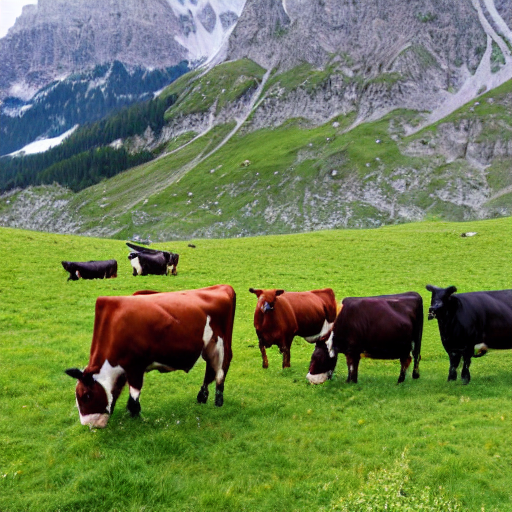

: 

In [ ]:
prompt = "Cows grazing on a mountain meadow in the alps"
gen_image = pipe(prompt, generator=generator).images[0]
gen_image